In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

2026-08-05 15:54:27.049035: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-05 15:54:27.206515: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
MODEL_PATH = "../models/resnet50_best.keras"
DATASET_PATH = "../dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 5000 files belonging to 5 classes.
Using 1000 files for validation.


In [8]:
best_model = load_model(MODEL_PATH)

print("Model loaded successfully!")

Model loaded successfully!


In [9]:
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,165,201 (96.00 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,051,660 (4.01 MB)

In [10]:
loss, accuracy = best_model.evaluate(val_ds)

print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy*100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9840 - loss: 0.0550

Validation Loss: 0.0550
Validation Accuracy: 98.40%


✅ Model loaded successfully!


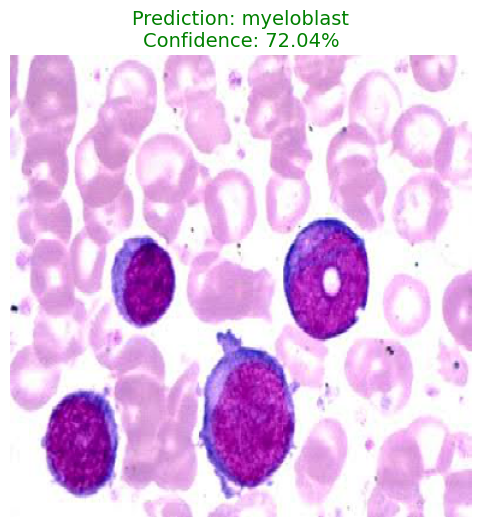

Predicted Cell : myeloblast
Confidence     : 72.04%

Class Probabilities:
basophil       : 5.47%
erythroblast   : 22.32%
monocyte       : 0.03%
myeloblast     : 72.04%
seg_neutrophil : 0.14%


In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# -------------------------------
# Load Trained Model
# -------------------------------
MODEL_PATH = "../models/resnet50_frozen_384.keras"

model = load_model(MODEL_PATH)

print("✅ Model loaded successfully!")

# -------------------------------
# Class Names
# -------------------------------
class_names = [
    "basophil",
    "erythroblast",
    "monocyte",
    "myeloblast",
    "seg_neutrophil"
]

# -------------------------------
# Image Size
# -------------------------------
IMG_SIZE = (384, 384)

# -------------------------------
# Prediction Function
# -------------------------------
def predict_image(img_path):
    # Load image
    img = tf.keras.utils.load_img(img_path, target_size=(384, 384))

    # Convert to array for prediction
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    # Predict
    pred = model.predict(img_array, verbose=0)

    predicted_idx = np.argmax(pred)
    predicted_class = class_names[predicted_idx]
    confidence = pred[0][predicted_idx] * 100

    # Display image
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%",
        fontsize=14,
        color="green"
    )
    plt.show()

    # Print probabilities
    print("=" * 50)
    print(f"Predicted Cell : {predicted_class}")
    print(f"Confidence     : {confidence:.2f}%")
    print("=" * 50)

    print("\nClass Probabilities:")
    for cls, prob in zip(class_names, pred[0]):
        print(f"{cls:15s}: {prob*100:.2f}%")

     

predict_image("../images/test2.jpg")
